# Getting started: discover a PDE from field data

KD recovers the Burgers equation from a bundled benchmark dataset whose equation is known. This notebook loads the data, inspects the field, fits a symbolic model in one call, compares the result with the known equation, and plots the convergence curve.

In [1]:
import kd

ds = kd.load_burgers()
print(ds.ground_truth)

u_t = -u * u_x + 0.1 * u_xx


## Look at the data

The dataset contains a field `u` sampled on an `(x, t)` grid. Before fitting, `kd.preview` prints the grid, the field, and the left-hand-side derivative that KD will use.

Dataset: burgers
Axes:
     x | n=256  | range [-8.000, 7.938] | step 0.0625 (uniform)
     t | n=201  | range [0.000, 10.000] | step 0.05 (uniform)
Fields:
     u | dtype=float64 | shape=(256, 201) | min=-1.000 max=1.000 mean=0.000 (NaN=0)
LHS: u_t  (field='u', axis='t')
Status: ready to fit


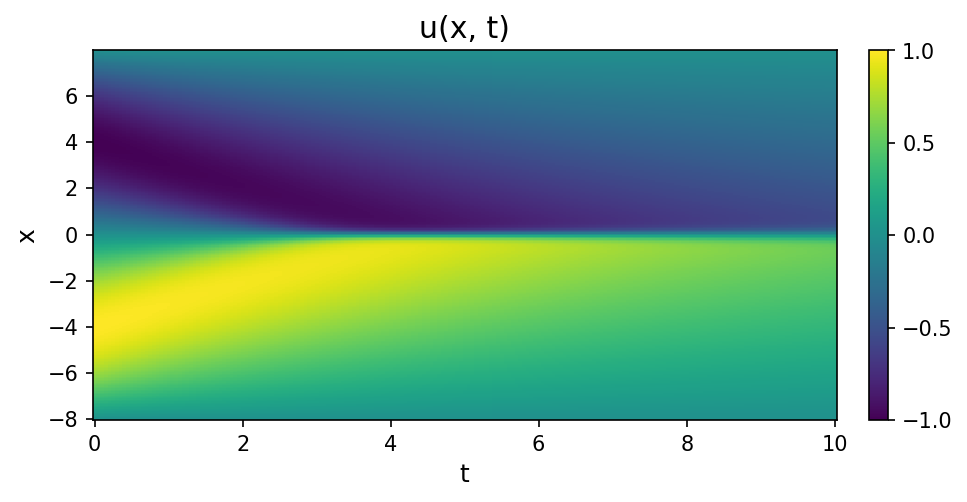

In [2]:
kd.preview(ds)
kd.viz.plots.plot_field(ds)

## Fit a model

SGA-PDE searches over symbolic expression trees and scores candidate right-hand sides against the target derivative. `generations` sets the search budget. The value below is small enough to run quickly and large enough to recover a Burgers-like equation.

In [3]:
model = kd.Model(algorithm="sga", generations=5, seed=0, verbose=False).fit(ds)
print(model.result_.equation)
print(model.best_score_)

u_t = -u*u_x + 0.1002*u_xx
-28.776750720652373


## Compare to ground truth

The discovered equation is KD's best symbolic right-hand side for `u_t`. The exact string can differ from the compact textbook form, so the check is whether it contains the nonlinear advection and diffusion terms.

In [4]:
print(f"Discovered  : {model.result_.equation}")
print(f"Ground truth: {ds.ground_truth}")

Discovered  : u_t = -u*u_x + 0.1002*u_xx
Ground truth: u_t = -u * u_x + 0.1 * u_xx


## Visualize

`plot_convergence` draws the recorded best-score curve, labels it with the
algorithm's score kind (AIC for SGA), and notes when the best score was reached
on the first iteration. It creates its own figure; the returned list contains
any plot notes.


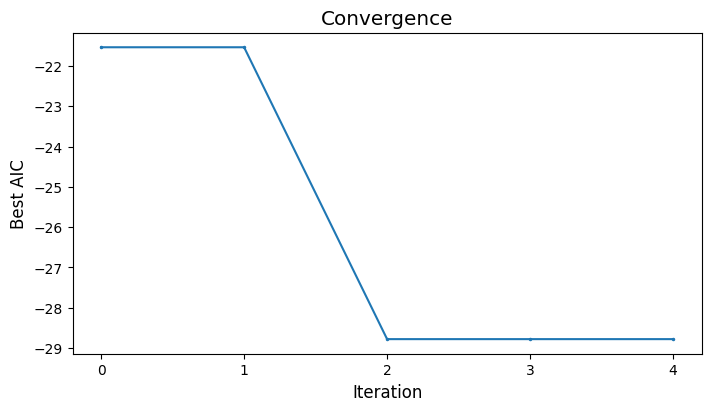

In [5]:
from kd.viz.plots import plot_convergence

plot_convergence(model.result_);

## The report

`model.report` writes every supported figure and an HTML report, and displays
the report here. The same files remain in the output directory.


In [6]:
model.report("../out/getting_started")

ReportResult(figures=[PosixPath('../out/getting_started/convergence.svg'), PosixPath('../out/getting_started/parity.svg'), PosixPath('../out/getting_started/equation.svg'), PosixPath('../out/getting_started/equation_tree.svg'), PosixPath('../out/getting_started/residual.svg'), PosixPath('../out/getting_started/coefficient_bar.svg'), PosixPath('../out/getting_started/field_comparison.svg'), PosixPath('../out/getting_started/pde_residual_field.svg'), PosixPath('../out/getting_started/time_slices.svg'), PosixPath('../out/getting_started/error_heatmap.svg'), PosixPath('../out/getting_started/plugin_population_diversity.svg'), PosixPath('../out/getting_started/plugin_complexity_evolution.svg'), PosixPath('../out/getting_started/plugin_fitness_spread.svg'), PosixPath('../out/getting_started/plugin_surrogate_training.svg'), PosixPath('../out/getting_started/plugin_genome_tree.svg')], data_files=[], report=PosixPath('../out/getting_started/report.html'), warnings=["plugin plot 'surrogate_training': No data (no surrogate training logged for this run)"])

## Next steps

This notebook used SGA-PDE. KD provides **seven algorithms** behind the same
`kd.Model` interface:

- Bring your own field data with [`examples/02_your_data.py`](../02_your_data.py).
- Compare all seven algorithms on one dataset against a single NMSE measure, with
  [`examples/09_compare_algorithms.py`](../09_compare_algorithms.py):
  SGA, DLGA, DISCOVER, PySR, PySINDy, EqGPT, and LLM4ED.
- Or run a single algorithm on its own: DISCOVER
  ([`07`](../07_discover.py)), DLGA ([`08`](../08_dlga.py)), EqGPT
  ([`16`](../16_eqgpt.py)), or LLM4ED ([`17`](../17_llm4ed.py)).